In [8]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
#Import necessary libraries

In [9]:
rng = np.random.default_rng(seed=21)
noise = 20*(rng.random((100))-.5)
data_no_noise = np.arange(5, 305, 3)
training_data = noise + data_no_noise
w=0
b=0
#Create synthetic data y=3x+5+noise and initialize w and b (weight and bias)

In [10]:

def cost(w_current,b_current):
    total_cost = 0
    for x, value in enumerate(training_data):
        total_cost += (value-(w_current*x+b_current))**2
    return total_cost/(2*training_data.size)
#define the cost function

In [11]:
def compute_gradient(w_current, b_current):
    dw_dj = 0
    db_dj = 0
    for x, value in enumerate(training_data):
        f_wb = w*x+b
        dw_dj_temp = (f_wb-value) * x
        db_dj_temp = (f_wb-value)
        dw_dj += dw_dj_temp
        db_dj += db_dj_temp
    dw_dj/= training_data.size
    db_dj/= training_data.size
    return dw_dj,db_dj
#define compute_gradient function

In [12]:
historical_cost = [cost(w,b)]
for i in range(1000):
    dw_dj, db_dj = compute_gradient(w,b)
    b = b-.005*db_dj
    w = w-.00005*(dw_dj)
    historical_cost.append(cost(w,b))
#implement gradient descent over 1000 iterations while recording cost history

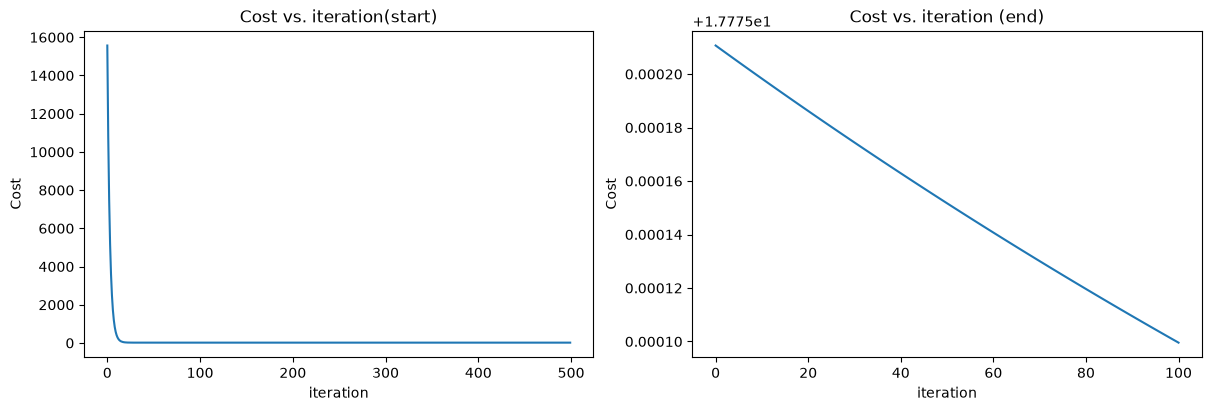

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(historical_cost[:500])
ax2.plot( historical_cost[900:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration')  ;  ax2.set_xlabel('iteration') 
plt.show()

#plot cost history to visualize the process of linear regression and gradient descent

In [14]:
model = sklearn.linear_model.LinearRegression()
x = np.arange(0,100)
model.fit(x.reshape(-1, 1), training_data)

w_sklearn = model.coef_[0]
b_sklearn = model.intercept_
print('my equation: ', w, 'x + ', b, '\n cost = ', cost(w,b), sep='')
print('sklearn equation: ', w_sklearn, 'x + ', b_sklearn, '\n cost = ', cost(w_sklearn,b_sklearn), sep='')
#Compare my equation to scikit-learns built in linear regression equation

my equation: 3.006357606854297x + 4.706970983642215
 cost = 17.77509957253584
sklearn equation: 3.0055109261160484x + 4.762709793660207
 cost = 17.77470529893066
